# **CIT 5900 Final Project - Beauty Product Rating Predictor**
**Team Members:** Amber Wang 33797828, Keanna Vaitohi 56083040


## 1. Data Loading & Pre-processing

### Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
sephora = pd.read_csv('/content/drive/MyDrive/sephora_website_dataset.csv')

### Analyzing Data Structure

In [4]:
sephora.shape

(9168, 21)

In [5]:
sephora.dtypes

,0
id,int64
brand,object
category,object
name,object
size,object
rating,float64
number_of_reviews,int64
love,int64
price,float64
value_price,float64


In [6]:
sephora.head(10)

,id,brand,category,name,size,rating,number_of_reviews,love,price,value_price,...,MarketingFlags,MarketingFlags_content,options,details,how_to_use,ingredients,online_only,exclusive,limited_edition,limited_time_offer
0,2218774,Acqua Di Parma,Fragrance,Blu Mediterraneo MINIATURE Set,5 x 0.16oz/5mL,4.0,4,3002,66.0,75.0,...,True,online only,no options,This enchanting set comes in a specially handc...,Suggested Usage:-Fragrance is intensified by t...,Arancia di Capri Eau de Toilette: Alcohol Dena...,1,0,0,0
1,2044816,Acqua Di Parma,Cologne,Colonia,0.7 oz/ 20 mL,4.5,76,2700,66.0,66.0,...,True,online only,- 0.7 oz/ 20 mL Spray - 1.7 oz/ 50 mL Eau d...,An elegant timeless scent filled with a fresh-...,no instructions,unknown,1,0,0,0
2,1417567,Acqua Di Parma,Perfume,Arancia di Capri,5 oz/ 148 mL,4.5,26,2600,180.0,180.0,...,True,online only,- 1oz/30mL Eau de Toilette - 2.5 oz/ 74 mL E...,Fragrance Family: Fresh Scent Type: Fresh Citr...,no instructions,Alcohol Denat.- Water- Fragrance- Limonene- Li...,1,0,0,0
3,1417617,Acqua Di Parma,Perfume,Mirto di Panarea,2.5 oz/ 74 mL,4.5,23,2900,120.0,120.0,...,True,online only,- 1 oz/ 30 mL Eau de Toilette Spray - 2.5 oz/...,Panarea near Sicily is an an island suspended ...,no instructions,unknown,1,0,0,0
4,2218766,Acqua Di Parma,Fragrance,Colonia Miniature Set,5 x 0.16oz/5mL,3.5,2,943,72.0,80.0,...,True,online only,no options,The Colonia Miniature Set comes in an iconic A...,Suggested Usage:-Fragrance is intensified by t...,Colonia: Alcohol Denat.- Water- Fragrance- Lim...,1,0,0,0
5,1417609,Acqua Di Parma,Perfume,Fico di Amalfi,5 oz/ 148 mL,4.5,79,2600,180.0,180.0,...,True,online only,- 1oz/30mL Eau de Toilette - 2.5 oz/ 74 mL E...,Fragrance Family: Floral Scent Type: Fruity Fl...,no instructions,unknown,1,0,0,0
6,1638832,Acqua Di Parma,Perfume,Rosa Nobile,3.4 oz/ 101 mL,4.5,79,5000,210.0,210.0,...,True,online only,"- 0.7 oz, 20 mL Eau de Parfum Spray - 1.7 oz/...",Fragrance Family: Floral\n\nScent Type: Classi...,no instructions,unknown,1,0,0,0
7,1284462,Acqua Di Parma,Cologne,Colonia Essenza,1.7 oz/ 50 mL,5.0,13,719,120.0,120.0,...,True,online only,- 1.7 oz/ 50 mL Eau de Cologne Spray - 3.4 o...,The newest Eau de Cologne from Acqua di Parma ...,no instructions,Alcohol Denat.- Water- Fragrance- Limonene- Hy...,1,0,0,0
8,2221588,Acqua Di Parma,Body Mist & Hair Mist,Peonia Nobile Hair Mist,1.7oz/50mL,4.0,5,800,58.0,58.0,...,True,online only,- 1.7oz/50mL Hair Mist - 0.70oz/20mL Eau de...,A new Le Nobili beauty ritual leaves your hair...,Suggested Usage:-Spray over your hair to leave...,Alcohol Denat.- Water- Fragrance- Polyquaterni...,1,0,0,0
9,2221596,Acqua Di Parma,Perfume,Rosa Nobile Hair Mist,1.7oz/50mL,3.0,5,2100,58.0,58.0,...,True,exclusive · online only,- 1.7oz/50mL Hair Mist,Fragrance Family: Floral\n\nScent Type: Classi...,Suggested Usage:-Spray over your hair to leave...,unknown,1,1,0,0


In [7]:
sephora.columns

Index(['id', 'brand', 'category', 'name', 'size', 'rating',
       'number_of_reviews', 'love', 'price', 'value_price', 'URL',
       'MarketingFlags', 'MarketingFlags_content', 'options', 'details',
       'how_to_use', 'ingredients', 'online_only', 'exclusive',
       'limited_edition', 'limited_time_offer'],
      dtype='object')

### Data Pre-processing

In [8]:
# check for missing values
sephora.isnull().sum()

,0
id,0
brand,0
category,0
name,0
size,0
rating,0
number_of_reviews,0
love,0
price,0
value_price,0


In [9]:
# drop unnecessary/text columns
sephora = sephora.drop(columns=['URL', 'size', 'options', 'details','how_to_use', 'ingredients'])

#### Categorical Variables

In [10]:
# brand
# group brands (only keep the top 20)
top_brands = sephora['brand'].value_counts().nlargest(20).index
sephora['brand_grouped'] = sephora['brand'].apply(
    lambda x: x if x in top_brands else 'Other'
)

# one-hot encoding
brand_dummies = pd.get_dummies(
    sephora['brand_grouped'],
    prefix='brand',
    drop_first=True,
    dtype=int
)

In [11]:
# category
# group categories (only keep the top 20)
top_categories = sephora['category'].value_counts().nlargest(20).index

sephora['category_grouped'] = sephora['category'].apply(
    lambda x: x if x in top_categories else 'Other'
)

# one-hot encoding
category_dummies = pd.get_dummies(
    sephora['category_grouped'],
    prefix='category',
    drop_first=True,
    dtype=int
)

In [12]:
# marketing flags content
flags = sephora['MarketingFlags_content'].fillna('0')

flags_dummies = (
    flags
    .str.replace(' · ', '|', regex=False)
    .str.get_dummies(sep='|')
)

flags_dummies = flags_dummies.drop(columns=['0'], errors='ignore')
flags_dummies = flags_dummies.add_prefix('flag_')

In [13]:
# encode marketing flags
sephora['MarketingFlags'] = sephora['MarketingFlags'].astype(int)

In [14]:
# create an encoded data frame for modeling
model_df = pd.concat([
    sephora[['price','rating','number_of_reviews','love','MarketingFlags']],
    brand_dummies,
    category_dummies,
    flags_dummies
], axis=1)

In [15]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 49 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   price                               9168 non-null   float64
 1   rating                              9168 non-null   float64
 2   number_of_reviews                   9168 non-null   int64  
 3   love                                9168 non-null   int64  
 4   MarketingFlags                      9168 non-null   int64  
 5   brand_Bumble and bumble             9168 non-null   int64  
 6   brand_CLINIQUE                      9168 non-null   int64  
 7   brand_Dior                          9168 non-null   int64  
 8   brand_FENTY BEAUTY by Rihanna       9168 non-null   int64  
 9   brand_Fresh                         9168 non-null   int64  
 10  brand_Jo Malone London              9168 non-null   int64  
 11  brand_Kiehl's Since 1851            9168 no

## 2. Exploratory Data Analysis

### rating

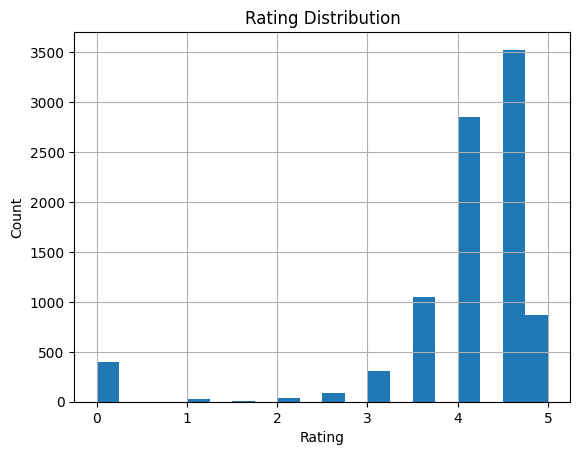

In [16]:
# rating (target variable) distribution
sephora['rating'].hist(bins=20)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

The rating distribution is skewed toward higher values (skewed to the right), with most products receiving ratings above 4.0. This shows a strong positive bias in customer reviews, where the majority of products are rated favorably, suggesting that people are more likely to leave reviews if they like the product.

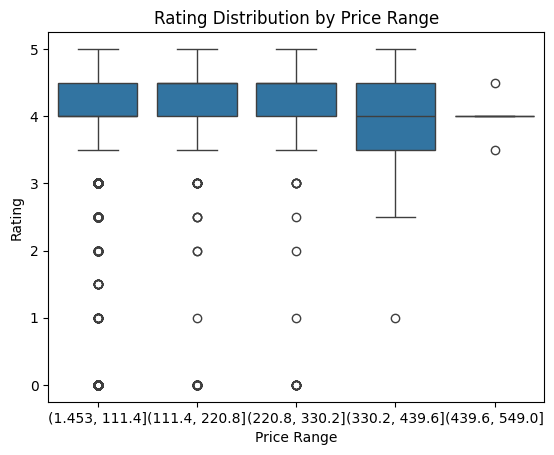

In [17]:
# price vs. rating
sns.boxplot(x=pd.cut(sephora['price'], bins=5), y=sephora['rating'])
plt.xlabel("Price Range")
plt.ylabel("Rating")
plt.title("Rating Distribution by Price Range")
plt.show()

Ratings remain relatively high across all price ranges, with no clear trend as price increases. This suggests that higher-priced products do not necessarily deliver better customer satisfaction, and that product quality perception is relatively stable across different price tiers.

#### brand and category

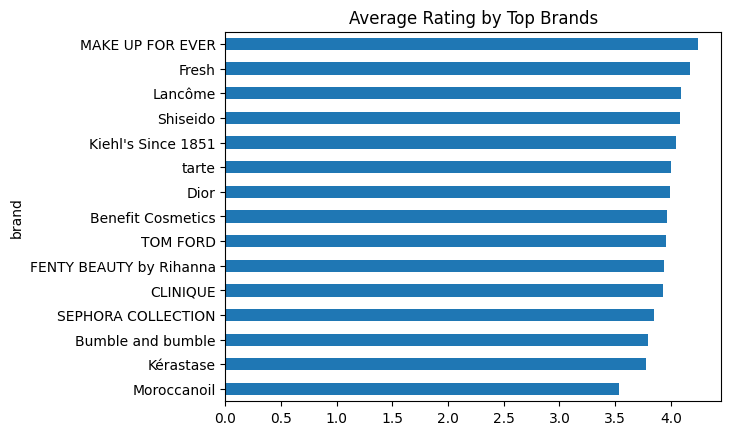

In [18]:
# brand analysis
top_brands = sephora['brand'].value_counts().nlargest(15).index

sephora[sephora['brand'].isin(top_brands)] \
    .groupby('brand')['rating'] \
    .mean() \
    .sort_values() \
    .plot(kind='barh')

plt.title('Average Rating by Top Brands')
plt.show()

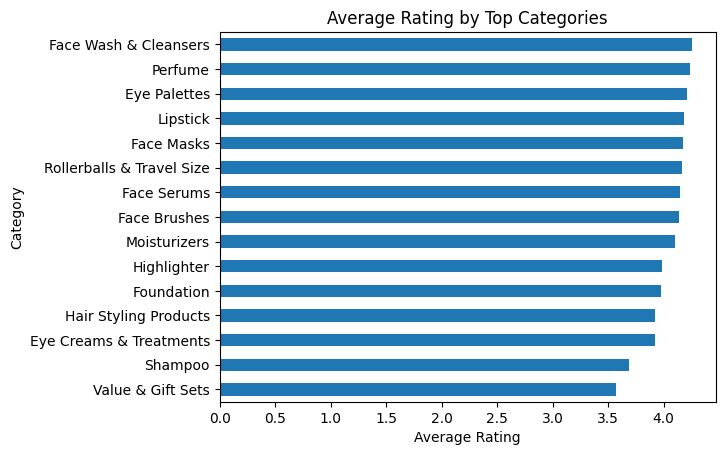

In [19]:
# category analysis
top_categories = sephora['category'].value_counts().nlargest(15).index

sephora[sephora['category'].isin(top_categories)] \
    .groupby('category')['rating'] \
    .mean() \
    .sort_values() \
    .plot(kind='barh')

plt.title('Average Rating by Top Categories')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.show()

While there are slight variations in average ratings across brands and categories, the differences are relatively small, with most values clustered between 3.5 and 4.5. This suggests that no single factor strongly determines product ratings, showing the need for a multi-feature predictive model.

#### selling channel

Counts:
exclusive
0    6741
1    2427
Name: count, dtype: int64

Average Rating:
exclusive
0    3.991
1    3.987
Name: rating, dtype: float64


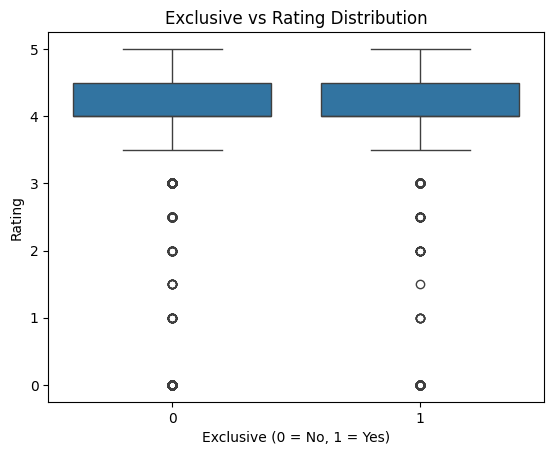

In [20]:
# impact of selling exclusively on Sephora's website
# summary stats
print("Counts:")
print(sephora['exclusive'].value_counts())
print("\nAverage Rating:")
print(sephora.groupby('exclusive')['rating'].mean().round(3))

# plot
sns.boxplot(x='exclusive', y='rating', data=sephora)
plt.title('Exclusive vs Rating Distribution')
plt.xlabel('Exclusive (0 = No, 1 = Yes)')
plt.ylabel('Rating')
plt.show()

There is no significant difference in rating distributions between exclusive and non-exclusive products, suggesting that exclusivity alone does not drive higher customer satisfaction.

#### review

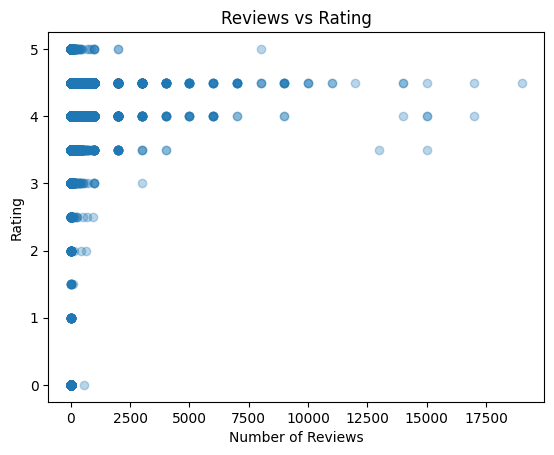

In [21]:
# popularity vs. rating
plt.scatter(sephora['number_of_reviews'], sephora['rating'], alpha=0.3)
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')
plt.title('Reviews vs Rating')
plt.show()
# does not seem very helpful?

Products with a higher number of reviews tend to have more stable and consistently high ratings, while products with fewer reviews exhibit greater variability.

### price

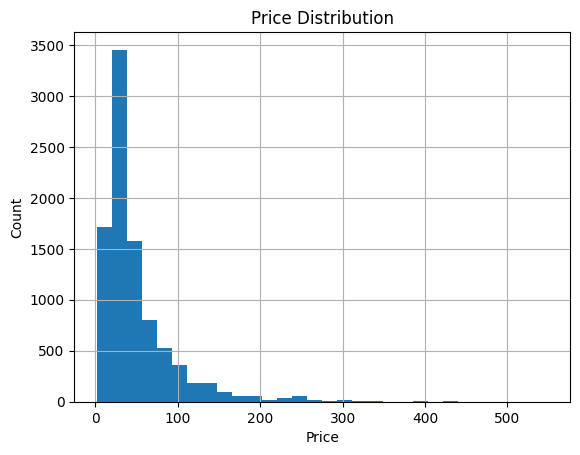

In [22]:
# price distribution
sephora['price'].hist(bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

The price distribution is right-skewed, with the majority of products concentrated in lower price ranges and a small number of high-priced outliers. This suggests that most products in the dataset are relatively affordable, with only a limited number of premium-priced items.

### marketing

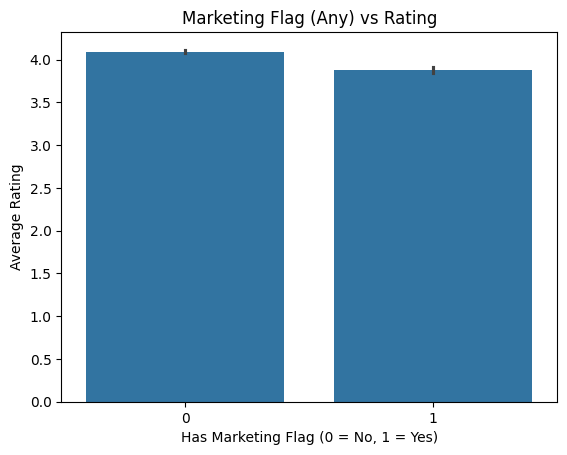

In [23]:
# marketing impacts
sns.barplot(x='MarketingFlags', y='rating', data=sephora)

plt.title('Marketing Flag (Any) vs Rating')
plt.xlabel('Has Marketing Flag (0 = No, 1 = Yes)')
plt.ylabel('Average Rating')
plt.show()

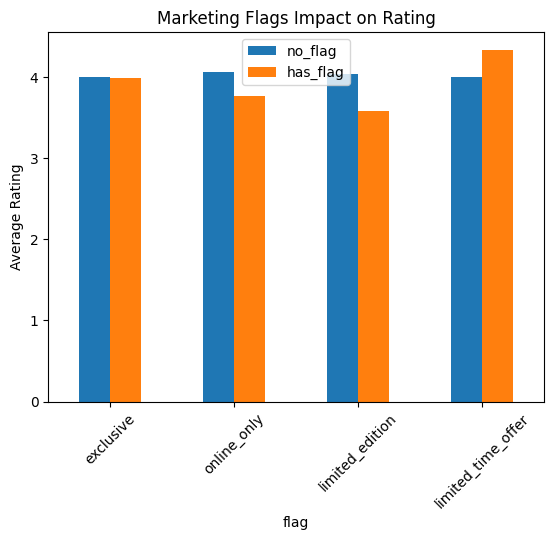

In [24]:
flags = ['exclusive', 'online_only', 'limited_edition', 'limited_time_offer']

avg_ratings = []

for col in flags:
    avg = sephora.groupby(col)['rating'].mean()
    avg_ratings.append({
        'flag': col,
        'no_flag': avg[0],
        'has_flag': avg[1]
    })

df_flags = pd.DataFrame(avg_ratings)

df_flags.set_index('flag').plot(kind='bar')

plt.title('Marketing Flags Impact on Rating')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

Marketing flags show a limited impact on product ratings. While a simple comparison suggests slightly lower ratings for marketed products, a more detailed breakdown reveals that the effect varies by marketing type. This indicates that marketing does not consistently improve customer satisfaction and its impact is not uniform.

### correlation

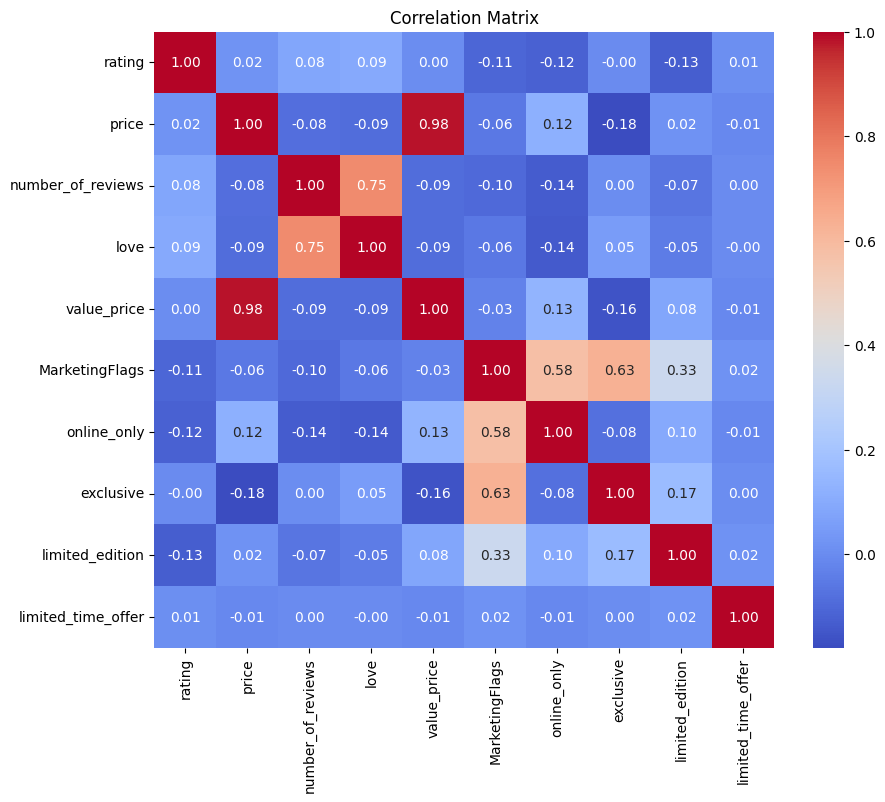

In [25]:
# correlation overview
numeric_cols = [
    'rating', 'price', 'number_of_reviews', 'love',
    'value_price',
    'MarketingFlags',
    'online_only', 'exclusive', 'limited_edition', 'limited_time_offer'
]

corr = sephora[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

The correlation analysis shows that product ratings have weak relationships with individual features such as price, reviews and marketing indicators. While some features are strongly correlated with each other, none exhibit a strong direct relationship with ratings. This suggests that customer satisfaction is influenced by a combination of factors rather than any single attribute.

## 3. Model with rating >= 4 as Threshold

In [26]:
# drop features that are not useful
model_df = model_df.drop(columns=['value_price','limited_time_offer'], errors='ignore')

In [27]:
# target
# set threshold at rating = 4
sephora['high_rating'] = (sephora['rating'] >= 4).astype(int)
model_df['high_rating'] = sephora['high_rating']

# features
X = model_df.drop(columns=['rating', 'high_rating'])
y = model_df['high_rating']

# clean column names
X.columns = X.columns.str.replace(' ', '_').str.replace('&', 'and')

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Logistic Regression

In [28]:
# scale numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['price', 'number_of_reviews', 'love']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [30]:
# build logistic regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)

# model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# predictions
y_pred = model.predict(X_test)

# print report and accuracy
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.27      0.01      0.01       400
           1       0.78      0.99      0.88      1434

    accuracy                           0.78      1834
   macro avg       0.53      0.50      0.45      1834
weighted avg       0.67      0.78      0.69      1834

Accuracy: 0.7791712104689203


### Logistic Regression Adjustments

In [31]:
# applying class weight
model = LogisticRegression(
    max_iter=1000,
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.32      0.73      0.45       400
           1       0.88      0.57      0.70      1434

    accuracy                           0.61      1834
   macro avg       0.60      0.65      0.57      1834
weighted avg       0.76      0.61      0.64      1834

Accuracy: 0.6074154852780806


### Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.64      0.29      0.40       400
           1       0.83      0.95      0.89      1434

    accuracy                           0.81      1834
   macro avg       0.73      0.62      0.64      1834
weighted avg       0.79      0.81      0.78      1834

Accuracy: 0.8091603053435115


#### Feature Importance

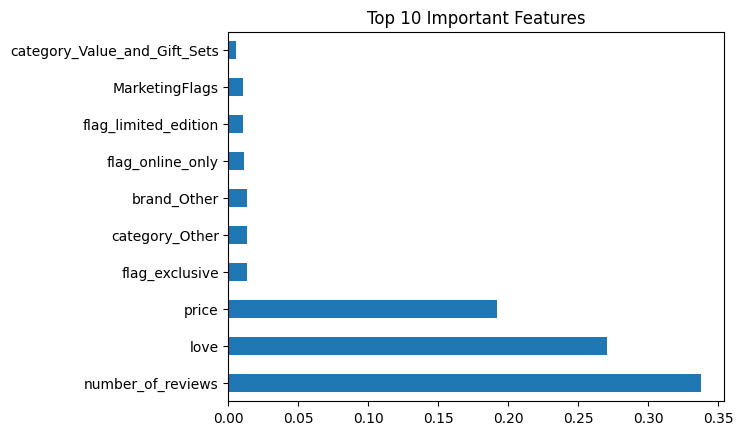

In [33]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

## 4. Model with rating >= 4.2 as Threshold

In [34]:
sephora['high_rating_42'] = (sephora['rating'] >= 4.2).astype(int)
model_df['high_rating_42'] = sephora['high_rating_42']

# check balance
print(sephora['high_rating_42'].value_counts(normalize=True))

high_rating_42
0    0.520179
1    0.479821
Name: proportion, dtype: float64


### Logistic Regression

In [35]:
X = model_df.drop(columns=['rating', 'high_rating', 'high_rating_42'])
y = model_df['high_rating_42']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
num_cols = ['price', 'number_of_reviews', 'love']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

model = LogisticRegression(
    max_iter=1000,
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.67      0.64       977
           1       0.58      0.51      0.54       857

    accuracy                           0.60      1834
   macro avg       0.59      0.59      0.59      1834
weighted avg       0.59      0.60      0.59      1834

Accuracy: 0.5965103598691385


### Random Forest

In [36]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.61      0.67      0.64       977
           1       0.58      0.51      0.54       857

    accuracy                           0.60      1834
   macro avg       0.59      0.59      0.59      1834
weighted avg       0.59      0.60      0.59      1834

Accuracy: 0.6210468920392584


Random Forest consistently outperforms Logistic Regression across both thresholds. While models achieve higher accuracy (around 81%) at a 4.0 threshold, this is influenced by class imbalance. Increasing the threshold to 4.2 creates a more balanced and challenging prediction task, resulting in lower but more meaningful accuracy (around 62%).

#### Feature Importance

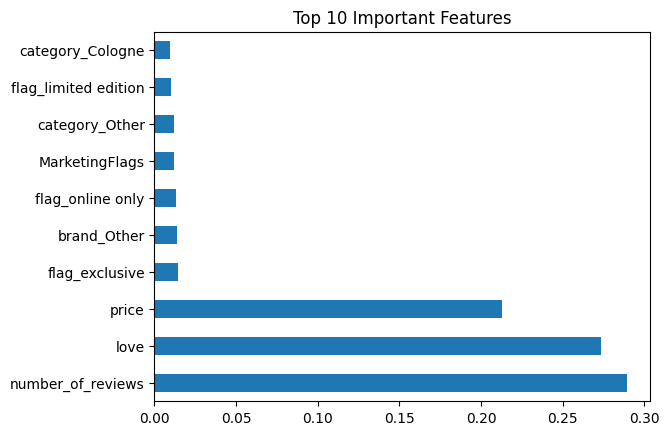

In [37]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

Feature importance analysis shows that engagement-related variables such as number of reviews and love counts are the strongest predictors of product ratings, while product attributes like brand, category and marketing flags contribute relatively little. Thus, customer engagement metrics appear to have a stronger impact than individual product categories or marketing-related features, suggesting that product popularity and user interaction are closely associated with higher ratings.

## Interactive Application

In [38]:
!pip install ipywidgets

### Random Forest Regressor

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# remove invalid ratings
regression_df = model_df[model_df['rating'] > 0].copy()

# target
y = regression_df['rating']

# features
X = regression_df.drop(
    columns=['rating'],
    errors='ignore'
)

# clean feature names
X.columns = (
    X.columns.astype(str)
    .str.replace(' ', '_', regex=False)
    .str.replace('&', 'and', regex=False)
)

# log transform skewed features
for col in ['love', 'number_of_reviews']:
    if col in X.columns:
        X[col] = np.log1p(X[col])

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# model
rf_regressor = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(X_train, y_train)

# predictiona and evaluation
y_pred = rf_regressor.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R²:", r2_score(y_test, y_pred))

MAE: 0.1944628910872255
RMSE: 0.3145355971856863
R²: 0.6695397461753179


Although classification models such as logistic regression can achieve good accuracy in predicting whether a product has a high rating, we use a Random Forest Regressor for the interactive application because it predicts continuous rating values. This allows users to see more precise and interpretable outputs (such as 3.7 instead of a binary 0/1 classification).

#### Simple UI with Widgets

In [63]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# helper function
def clean_col(text):
    return (
        str(text)
        .replace(' ', '_')
        .replace('&', 'and')
    )

# get dropdown options
top_categories = sephora['category'].dropna().value_counts().head(10).index.tolist()
top_brands = sephora['brand'].dropna().value_counts().head(10).index.tolist()

# widgets
price_slider = widgets.FloatSlider(
    value=35,
    min=0,
    max=float(sephora['price'].max()),
    step=1,
    description='Price:'
)

category_dropdown = widgets.Dropdown(
    options=top_categories + ['Other'],
    description='Category:'
)

brand_dropdown = widgets.Dropdown(
    options=[],
    description='Brand:'
)

exclusive_checkbox = widgets.Checkbox(value=False, description='Exclusive')
online_checkbox = widgets.Checkbox(value=False, description='Online Only')

predict_button = widgets.Button(
    description='Predict Rating',
    button_style='success'
)

output = widgets.Output()

# update brand options based on category
def update_brands(change=None):
    selected_category = category_dropdown.value

    if selected_category != 'Other':
        brands = (
            sephora[sephora['category'] == selected_category]['brand']
            .dropna()
            .value_counts()
            .head(10)
            .index
            .tolist()
        )
    else:
        brands = top_brands

    brand_dropdown.options = brands + ['Other']
    brand_dropdown.value = brand_dropdown.options[0]

category_dropdown.observe(update_brands, names='value')
update_brands()

# prediction function
def predict_rating_clicked(b):
    with output:
        clear_output()

        # create one empty row using EXACT training columns
        input_data = pd.DataFrame(0, index=[0], columns=X_train.columns)

        # price
        if 'price' in input_data.columns:
            input_data.loc[0, 'price'] = price_slider.value

        # marketing flag
        if 'MarketingFlags' in input_data.columns:
            input_data.loc[0, 'MarketingFlags'] = int(
                exclusive_checkbox.value or online_checkbox.value
            )

        # category
        if category_dropdown.value != 'Other':
            category_col = 'category_' + clean_col(category_dropdown.value)
            if category_col in input_data.columns:
                input_data.loc[0, category_col] = 1

        # brand
        if brand_dropdown.value != 'Other':
            brand_col = 'brand_' + clean_col(brand_dropdown.value)
            if brand_col in input_data.columns:
                input_data.loc[0, brand_col] = 1

        # force exact training column order
        input_data = input_data.reindex(columns=X_train.columns, fill_value=0)

        # predict
        prediction = rf_regressor.predict(input_data)[0]

        print(f"Predicted Rating: {prediction:.2f}")

predict_button.on_click(predict_rating_clicked)

# display UI
display(
    price_slider,
    category_dropdown,
    brand_dropdown,
    exclusive_checkbox,
    online_checkbox,
    predict_button,
    output
)

FloatSlider(value=35.0, description='Price:', max=549.0, step=1.0)

Dropdown(description='Category:', options=('Perfume', 'Moisturizers', 'Face Serums', 'Value & Gift Sets', 'Fac…

Dropdown(description='Brand:', options=('TOM FORD', 'Jo Malone London', 'CLEAN RESERVE', 'Atelier Cologne', 'C…

Checkbox(value=False, description='Exclusive')

Checkbox(value=False, description='Online Only')

Button(button_style='success', description='Predict Rating', style=ButtonStyle())

Output()

### Random Forest Classifier

- using rating >= 4.2 as threshold

#### Simple UI with Widget

In [64]:
# create target
model_df['high_rating'] = (model_df['rating'] >= 4.2).astype(int)

# clean column names
model_df_clean = model_df.copy()
model_df_clean.columns = (
    model_df_clean.columns.astype(str)
    .str.replace(' ', '_', regex=False)
    .str.replace('&', 'and', regex=False)
)

# only keeping columns used in the UI
ui_columns = ['price']

if 'MarketingFlags' in model_df_clean.columns:
    ui_columns.append('MarketingFlags')

ui_columns += [
    col for col in model_df_clean.columns
    if col.startswith('brand_') or col.startswith('category_')
]

X = model_df_clean[ui_columns]
y = model_df_clean['high_rating']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# model
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_classifier.fit(X_train, y_train)

# prediction and evaluation
y_pred_rf = rf_classifier.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.56      0.85      0.68       954
           1       0.64      0.29      0.40       880

    accuracy                           0.58      1834
   macro avg       0.60      0.57      0.54      1834
weighted avg       0.60      0.58      0.54      1834

Accuracy: 0.579607415485278


In [65]:
# top dropdown options
top_categories = sephora['category'].dropna().value_counts().head(10).index.tolist()
top_brands = sephora['brand'].dropna().value_counts().head(10).index.tolist()

# widgets
price_slider = widgets.FloatSlider(
    value=35,
    min=0,
    max=450,
    step=1,
    description='Price:'
)

category_dropdown = widgets.Dropdown(
    options=top_categories + ['Other'],
    description='Category:'
)

brand_dropdown = widgets.Dropdown(
    options=[],
    description='Brand:'
)

exclusive_checkbox = widgets.Checkbox(value=False, description='Exclusive')
online_checkbox = widgets.Checkbox(value=False, description='Online Only')

predict_button = widgets.Button(description='Predict', button_style='success')
output = widgets.Output()


def clean_text(text):
    return (
        str(text)
        .replace(' ', '_')
        .replace('&', 'and')
    )


def find_matching_column(prefix, value, columns):
    target_col = prefix + clean_text(value)

    if target_col in columns:
        return target_col

    return None


# update brand dropdown based on selected category
def update_brands(change=None):
    selected_category = category_dropdown.value

    if selected_category != 'Other':
        category_brands = (
            sephora[sephora['category'] == selected_category]['brand']
            .dropna()
            .value_counts()
            .index
            .tolist()
        )

        valid_brands = []
        for brand in category_brands:
            matched_col = find_matching_column('brand_', brand, X_train.columns)
            if matched_col is not None:
                valid_brands.append(brand)

    else:
        valid_brands = top_brands

    if len(valid_brands) == 0:
        new_options = ['Other']
    else:
        new_options = valid_brands[:10] + ['Other']

    brand_dropdown.options = new_options
    brand_dropdown.value = new_options[0]


category_dropdown.observe(update_brands, names='value')
update_brands()


# prediction function
def predict_rating_clicked(b):
    with output:
        clear_output()

        input_data = pd.DataFrame(0, index=[0], columns=X_train.columns)

        # price
        if 'price' in input_data.columns:
            input_data.loc[0, 'price'] = price_slider.value

        # marketing flag
        if 'MarketingFlags' in input_data.columns:
            input_data.loc[0, 'MarketingFlags'] = int(
                exclusive_checkbox.value or online_checkbox.value
            )

        # category
        if category_dropdown.value != 'Other':
            category_col = find_matching_column(
                'category_', category_dropdown.value, X_train.columns
            )

            if category_col is not None:
                input_data.loc[0, category_col] = 1

        # brand
        if brand_dropdown.value != 'Other':
            brand_col = find_matching_column(
                'brand_', brand_dropdown.value, X_train.columns
            )

            if brand_col is not None:
                input_data.loc[0, brand_col] = 1

        # force same column order
        input_data = input_data[X_train.columns]

        # predict
        prediction = rf_classifier.predict(input_data)[0]
        prediction_prob = rf_classifier.predict_proba(input_data)[0]

        if prediction == 1:
            print("Prediction: Highly Rated")
        else:
            print("Prediction: Not Highly Rated")


predict_button.on_click(predict_rating_clicked)


display(
    price_slider,
    category_dropdown,
    brand_dropdown,
    exclusive_checkbox,
    online_checkbox,
    predict_button,
    output
)

FloatSlider(value=35.0, description='Price:', max=450.0, step=1.0)

Dropdown(description='Category:', options=('Perfume', 'Moisturizers', 'Face Serums', 'Value & Gift Sets', 'Fac…

Dropdown(description='Brand:', options=('TOM FORD', 'Jo Malone London', 'Dior', 'Yves Saint Laurent', 'philoso…

Checkbox(value=False, description='Exclusive')

Checkbox(value=False, description='Online Only')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()